Contains Baseline Comparative Evaluation, Ablation Analysis, Statistical Testing, Sensitivity Analysis, Qualitative Analysis of Predictions and Errors

### LLMs Baseline

#### microsoft/phi-2, Acc- 0.7155, Spearman- 0.4561

In [ ]:
!pip install -q --upgrade \
    accelerate \
    transformers \
    peft \
    bitsandbytes \
    sentencepiece

import importlib, gc, torch, numpy as np
print("✓ Dependencies ready  –  torch", torch.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.3 MB/s eta 0:00:00
✓ Dependencies ready  –  torch 2.6.0+cu124


In [ ]:
import pandas as pd
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()


unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

# Use only Validation Split
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

Using device: cuda
Unlabeled set size: 58649
Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


In [ ]:
import torch, gc, random, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          BitsAndBytesConfig)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

MODEL_NAME = "microsoft/phi-2"
BATCH_T,BATCH_E,EPOCHS,LR,MAXLEN = 4,8,3,2e-4,256
set_seed = lambda s: (random.seed(s), np.random.seed(s),
                      torch.manual_seed(s), torch.cuda.manual_seed_all(s))
set_seed(42); device = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token_id is None:                        # add real PAD
    tok.add_special_tokens({'pad_token': tok.eos_token})

class DS(Dataset):
    def __init__(self, df):
        enc = tok(df["combined_input"].tolist(),
                  padding="max_length", truncation=True,
                  max_length=MAXLEN, return_tensors="pt")
        self.ids, self.msk = enc["input_ids"], enc["attention_mask"]
        self.lab = torch.tensor(df["label"].astype(int).values)
        self.score = torch.tensor(df.get("p(Hallucination)",
                                         pd.Series([0]*len(df))).astype(float).values)
    def __len__(self): return len(self.lab)
    def __getitem__(self,i):
        return {"input_ids":self.ids[i],"attention_mask":self.msk[i],
                "labels":self.lab[i],"score":self.score[i]}

train_dl = DataLoader(DS(val_df), batch_size=BATCH_T, shuffle=True)
test_dl  = DataLoader(DS(test_df), batch_size=BATCH_E)

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_use_double_quant=True,
                         bnb_4bit_compute_dtype=torch.float16,
                         llm_int8_enable_fp32_cpu_offload=True)

base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=bnb,
        num_labels=2, device_map="auto")
base.resize_token_embeddings(len(tok))
base.config.pad_token_id = tok.pad_token_id
base = prepare_model_for_kbit_training(base)

lora = LoraConfig(r=8,lora_alpha=32,lora_dropout=0.05,
                  target_modules=["q_proj","k_proj","v_proj","o_proj"],
                  bias="none",task_type="SEQ_CLS")
model = get_peft_model(base,lora)
opt   = torch.optim.AdamW(model.parameters(), lr=LR)

model.train()
for ep in range(EPOCHS):
    tot=0
    for b in tqdm(train_dl,desc=f"ep{ep+1}"):
        opt.zero_grad()
        loss = model(input_ids=b["input_ids"].to(device),
                     attention_mask=b["attention_mask"].to(device),
                     labels=b["labels"].to(device)).loss
        loss.backward(); opt.step(); tot+=loss.item()
    print(f"epoch{ep+1} loss {tot/len(train_dl):.4f}")
    torch.cuda.empty_cache(); gc.collect()

model.eval(); prob,pred,true,score=[],[],[],[]
with torch.no_grad():
    for b in tqdm(test_dl):
        logits = model(input_ids=b["input_ids"].to(device),
                       attention_mask=b["attention_mask"].to(device)).logits
        p = torch.softmax(logits,dim=1)[:,1].cpu().numpy()
        prob.extend(p); pred.extend((p>0.5).astype(int))
        true.extend(b["labels"].numpy()); score.extend(b["score"].numpy())
acc = accuracy_score(true,pred)
rho = spearmanr(score,prob).correlation if sum(score)>0 else None
print(f"Accuracy={acc:.4f}  Spearman={rho:.4f}" if rho else f"Accuracy={acc:.4f}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

epoch2 loss 0.6344


ep3:   0%|          | 0/250 [00:00<?, ?it/s]

epoch3 loss 0.4814


  0%|          | 0/375 [00:00<?, ?it/s]

Accuracy=0.7155  Spearman=0.4561


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import spearmanr
import numpy as np
from tqdm import tqdm
import torch

model.eval()
prob, pred, true, score = [], [], [], []

with torch.no_grad():
    for b in tqdm(test_dl):
        logits = model(
            input_ids=b["input_ids"].to(device),
            attention_mask=b["attention_mask"].to(device)
        ).logits
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        prob.extend(p)
        pred.extend((p > 0.5).astype(int))
        true.extend(b["labels"].numpy())
        score.extend(b["score"].numpy())

# Convert to numpy arrays
true = np.array(true)
pred = np.array(pred)
prob = np.array(prob)
score = np.array(score)

# Evaluation Metrics
acc = accuracy_score(true, pred)
rho = spearmanr(score, prob).correlation if np.sum(score) > 0 else None
cm = confusion_matrix(true, pred)
report = classification_report(true, pred, digits=4)

# Print Results
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)
if rho is not None:
    print(f"Spearman Correlation: {rho:.4f}")
else:
    print("Spearman Correlation: Not computed (score values missing or zero)")

100%|██████████| 375/375 [20:14<00:00,  3.24s/it]

Accuracy: 0.7155
Classification Report:
              precision    recall  f1-score   support

           0     0.7518    0.7993    0.7748      1834
           1     0.6478    0.5831    0.6138      1161

    accuracy                         0.7155      2995
   macro avg     0.6998    0.6912    0.6943      2995
weighted avg     0.7115    0.7155    0.7124      2995

Confusion Matrix:
[[1466  368]
 [ 484  677]]
Spearman Correlation: 0.4561


####  TinyLlama/TinyLlama-1.1B-Chat-v1.0 - Acc- 0.7135, Spearman- 0.4847

In [ ]:
# !pip install evaluate datasets
# import evaluate
#!huggingface-cli login
#!pip install transformers peft bitsandbytes accelerate
!pip install -U bitsandbytes

In [ ]:
!pip install -q --upgrade \
    accelerate \
    transformers \
    peft \
    bitsandbytes \
    sentencepiece



import importlib, gc, torch, numpy as np
print("✓ Dependencies ready  –  torch", torch.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.3 MB/s eta 0:00:00
✓ Dependencies ready  –  torch 2.6.0+cu124


In [ ]:
import pandas as pd
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()


unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

# Use only Validation Split
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

Using device: cuda
Unlabeled set size: 58649
Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


In [ ]:
# --------------------------------------------
# Tiny‑/3 B Llama LoRA baseline (binary + ρ)
# --------------------------------------------
import torch, gc, random, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          BitsAndBytesConfig)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
BATCH_T,BATCH_E,EPOCHS,LR,MAXLEN = 4,8,5,2e-4,256
set_seed = lambda s: (random.seed(s), np.random.seed(s),
                      torch.manual_seed(s), torch.cuda.manual_seed_all(s))
set_seed(42); device = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token_id is None:
    tok.add_special_tokens({'pad_token': tok.eos_token})

class DS(Dataset):
    def __init__(self, df):
        enc = tok(df["combined_input"].tolist(),
                  padding="max_length", truncation=True,
                  max_length=MAXLEN, return_tensors="pt")
        self.ids, self.msk = enc["input_ids"], enc["attention_mask"]
        self.lab = torch.tensor(df["label"].astype(int).values)
        self.score = torch.tensor(df.get("p(Hallucination)",
                                         pd.Series([0]*len(df))).astype(float).values)
    def __len__(self): return len(self.lab)
    def __getitem__(self,i):
        return {"input_ids":self.ids[i],"attention_mask":self.msk[i],
                "labels":self.lab[i],"score":self.score[i]}

train_dl = DataLoader(DS(val_df), batch_size=BATCH_T, shuffle=True)
test_dl  = DataLoader(DS(test_df), batch_size=BATCH_E)

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_use_double_quant=True,
                         bnb_4bit_compute_dtype=torch.float16,
                         llm_int8_enable_fp32_cpu_offload=True)

base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=bnb,
        num_labels=2, device_map="auto")
base.resize_token_embeddings(len(tok))
base.config.pad_token_id = tok.pad_token_id
base = prepare_model_for_kbit_training(base)

lora = LoraConfig(r=8,lora_alpha=32,lora_dropout=0.05,
                  target_modules=["q_proj","k_proj","v_proj","o_proj"],
                  bias="none",task_type="SEQ_CLS")
model = get_peft_model(base,lora)
opt   = torch.optim.AdamW(model.parameters(), lr=LR)

model.train()
for ep in range(EPOCHS):
    tot=0
    for b in tqdm(train_dl,desc=f"ep{ep+1}"):
        opt.zero_grad()
        loss = model(input_ids=b["input_ids"].to(device),
                     attention_mask=b["attention_mask"].to(device),
                     labels=b["labels"].to(device)).loss
        loss.backward(); opt.step(); tot+=loss.item()
    print(f"epoch{ep+1} loss {tot/len(train_dl):.4f}")
    torch.cuda.empty_cache(); gc.collect()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import spearmanr
import numpy as np
from tqdm import tqdm
import torch

model.eval()
prob, pred, true, score = [], [], [], []

with torch.no_grad():
    for b in tqdm(test_dl):
        logits = model(
            input_ids=b["input_ids"].to(device),
            attention_mask=b["attention_mask"].to(device)
        ).logits
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        prob.extend(p)
        pred.extend((p > 0.5).astype(int))
        true.extend(b["labels"].numpy())
        score.extend(b["score"].numpy())

# Convert to numpy arrays
true = np.array(true)
pred = np.array(pred)
prob = np.array(prob)
score = np.array(score)

# Evaluation Metrics
acc = accuracy_score(true, pred)
rho = spearmanr(score, prob).correlation if np.sum(score) > 0 else None
cm = confusion_matrix(true, pred)
report = classification_report(true, pred, digits=4)

# Print Results
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)
if rho is not None:
    print(f"Spearman Correlation: {rho:.4f}")
else:
    print("Spearman Correlation: Not computed (score values missing or zero)")

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

...

epoch4 loss 0.1660


ep5:   0%|          | 0/250 [00:00<?, ?it/s]

epoch5 loss 0.1128


100%|██████████| 375/375 [07:23<00:00,  1.18s/it]

Accuracy: 0.7135
Classification Report:
              precision    recall  f1-score   support

           0     0.7371    0.8272    0.7795      1834
           1     0.6617    0.5340    0.5910      1161

    accuracy                         0.7135      2995
   macro avg     0.6994    0.6806    0.6853      2995
weighted avg     0.7079    0.7135    0.7065      2995

Confusion Matrix:
[[1517  317]
 [ 541  620]]
Spearman Correlation: 0.4847


#### Meta‑llama/Llama‑3.2‑3B, Acc-0.7175, Spearman- 0.5111

In [ ]:
import pandas as pd
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = cleaned_df[ cleaned_df['Dataset'].str.contains('Train') ].copy()


unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

# Use only Validation Split
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

val_df = labeled_df[labeled_df['Dataset'].str.contains('Val')]
test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')]

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

Using device: cuda
Unlabeled set size: 58649
Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


In [ ]:
import torch, gc, random, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          BitsAndBytesConfig)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

MODEL_NAME = "Meta-llama/Llama-3.2-3B"   # swap here
# VAL_DF_PATH  = "/content/val_df.csv"
# TEST_DF_PATH = "/content/test_df.csv"
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

BATCH_T,BATCH_E,EPOCHS,LR,MAXLEN = 4,8,5,2e-4,256
set_seed = lambda s: (random.seed(s), np.random.seed(s),
                      torch.manual_seed(s), torch.cuda.manual_seed_all(s))
set_seed(42); device = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token_id is None:                        # add real PAD
    tok.add_special_tokens({'pad_token': tok.eos_token})

class DS(Dataset):
    def __init__(self, df):
        enc = tok(df["combined_input"].tolist(),
                  padding="max_length", truncation=True,
                  max_length=MAXLEN, return_tensors="pt")
        self.ids, self.msk = enc["input_ids"], enc["attention_mask"]
        self.lab = torch.tensor(df["label"].astype(int).values)
        self.score = torch.tensor(df.get("p(Hallucination)",
                                         pd.Series([0]*len(df))).astype(float).values)
    def __len__(self): return len(self.lab)
    def __getitem__(self,i):
        return {"input_ids":self.ids[i],"attention_mask":self.msk[i],
                "labels":self.lab[i],"score":self.score[i]}

train_dl = DataLoader(DS(val_df), batch_size=BATCH_T, shuffle=True)
test_dl  = DataLoader(DS(test_df), batch_size=BATCH_E)

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_use_double_quant=True,
                         bnb_4bit_compute_dtype=torch.float16,
                         llm_int8_enable_fp32_cpu_offload=True)

base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=bnb,
        num_labels=2, device_map="auto")
base.resize_token_embeddings(len(tok))
base.config.pad_token_id = tok.pad_token_id
base = prepare_model_for_kbit_training(base)

lora = LoraConfig(r=8,lora_alpha=32,lora_dropout=0.05,
                  target_modules=["q_proj","k_proj","v_proj","o_proj"],
                  bias="none",task_type="SEQ_CLS")
model = get_peft_model(base,lora)
opt   = torch.optim.AdamW(model.parameters(), lr=LR)

model.train()
for ep in range(EPOCHS):
    tot=0
    for b in tqdm(train_dl,desc=f"ep{ep+1}"):
        opt.zero_grad()
        loss = model(input_ids=b["input_ids"].to(device),
                     attention_mask=b["attention_mask"].to(device),
                     labels=b["labels"].to(device)).loss
        loss.backward(); opt.step(); tot+=loss.item()
    print(f"epoch{ep+1} loss {tot/len(train_dl):.4f}")
    torch.cuda.empty_cache(); gc.collect()
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import spearmanr
import numpy as np
from tqdm import tqdm
import torch

model.eval()
prob, pred, true, score = [], [], [], []

with torch.no_grad():
    for b in tqdm(test_dl):
        logits = model(
            input_ids=b["input_ids"].to(device),
            attention_mask=b["attention_mask"].to(device)
        ).logits
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        prob.extend(p)
        pred.extend((p > 0.5).astype(int))
        true.extend(b["labels"].numpy())
        score.extend(b["score"].numpy())

# Convert to numpy arrays
true = np.array(true)
pred = np.array(pred)
prob = np.array(prob)
score = np.array(score)

# Evaluation Metrics
acc = accuracy_score(true, pred)
rho = spearmanr(score, prob).correlation if np.sum(score) > 0 else None
cm = confusion_matrix(true, pred)
report = classification_report(true, pred, digits=4)

# Print Results
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)
if rho is not None:
    print(f"Spearman Correlation: {rho:.4f}")
else:
    print("Spearman Correlation: Not computed (score values missing or zero)")


Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

epoch4 loss 0.4825


ep5:   0%|          | 0/250 [00:00<?, ?it/s]

epoch5 loss 0.2642


100%|██████████| 375/375 [20:17<00:00,  3.25s/it]

Accuracy: 0.7175
Classification Report:
              precision    recall  f1-score   support

           0     0.7708    0.7666    0.7687      1834
           1     0.6345    0.6400    0.6372      1161

    accuracy                         0.7175      2995
   macro avg     0.7027    0.7033    0.7030      2995
weighted avg     0.7180    0.7175    0.7177      2995

Confusion Matrix:
[[1406  428]
 [ 418  743]]
Spearman Correlation: 0.5111


#### orca_mini_3b, Acc - 0.7152, Spearman- 0.5172

In [ ]:
import torch, gc, random, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          BitsAndBytesConfig)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

MODEL_NAME = "pankajmathur/orca_mini_3b"
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

BATCH_T,BATCH_E,EPOCHS,LR,MAXLEN = 4,8,5,2e-4,256
set_seed = lambda s: (random.seed(s), np.random.seed(s),
                      torch.manual_seed(s), torch.cuda.manual_seed_all(s))
set_seed(42); device = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token_id is None:                        # add real PAD
    tok.add_special_tokens({'pad_token': tok.eos_token})

class DS(Dataset):
    def __init__(self, df):
        enc = tok(df["combined_input"].tolist(),
                  padding="max_length", truncation=True,
                  max_length=MAXLEN, return_tensors="pt")
        self.ids, self.msk = enc["input_ids"], enc["attention_mask"]
        self.lab = torch.tensor(df["label"].astype(int).values)
        self.score = torch.tensor(df.get("p(Hallucination)",
                                         pd.Series([0]*len(df))).astype(float).values)
    def __len__(self): return len(self.lab)
    def __getitem__(self,i):
        return {"input_ids":self.ids[i],"attention_mask":self.msk[i],
                "labels":self.lab[i],"score":self.score[i]}

train_dl = DataLoader(DS(val_df), batch_size=BATCH_T, shuffle=True)
test_dl  = DataLoader(DS(test_df), batch_size=BATCH_E)

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_use_double_quant=True,
                         bnb_4bit_compute_dtype=torch.float16,
                         llm_int8_enable_fp32_cpu_offload=True)

base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=bnb,
        num_labels=2, device_map="auto")
base.resize_token_embeddings(len(tok))
base.config.pad_token_id = tok.pad_token_id
base = prepare_model_for_kbit_training(base)

lora = LoraConfig(r=8,lora_alpha=32,lora_dropout=0.05,
                  target_modules=["q_proj","k_proj","v_proj","o_proj"],
                  bias="none",task_type="SEQ_CLS")
model = get_peft_model(base,lora)
opt   = torch.optim.AdamW(model.parameters(), lr=LR)

model.train()
for ep in range(EPOCHS):
    tot=0
    for b in tqdm(train_dl,desc=f"ep{ep+1}"):
        opt.zero_grad()
        loss = model(input_ids=b["input_ids"].to(device),
                     attention_mask=b["attention_mask"].to(device),
                     labels=b["labels"].to(device)).loss
        loss.backward(); opt.step(); tot+=loss.item()
    print(f"epoch{ep+1} loss {tot/len(train_dl):.4f}")
    torch.cuda.empty_cache(); gc.collect()

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import spearmanr
import numpy as np
from tqdm import tqdm
import torch

model.eval()
prob, pred, true, score = [], [], [], []

with torch.no_grad():
    for b in tqdm(test_dl):
        logits = model(
            input_ids=b["input_ids"].to(device),
            attention_mask=b["attention_mask"].to(device)
        ).logits
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        prob.extend(p)
        pred.extend((p > 0.5).astype(int))
        true.extend(b["labels"].numpy())
        score.extend(b["score"].numpy())

# Convert to numpy arrays
true = np.array(true)
pred = np.array(pred)
prob = np.array(prob)
score = np.array(score)

# Evaluation Metrics
acc = accuracy_score(true, pred)
rho = spearmanr(score, prob).correlation if np.sum(score) > 0 else None
cm = confusion_matrix(true, pred)
report = classification_report(true, pred, digits=4)

# Print Results
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)
if rho is not None:
    print(f"Spearman Correlation: {rho:.4f}")
else:
    print("Spearman Correlation: Not computed (score values missing or zero)")

Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/534k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.98M [00:00<?, ?B/s]

...

epoch4 loss 0.1031


ep5:   0%|          | 0/250 [00:00<?, ?it/s]

epoch5 loss 0.0755


100%|██████████| 375/375 [25:22<00:00,  4.06s/it]

Accuracy: 0.7152
Classification Report:
              precision    recall  f1-score   support

           0     0.7067    0.9144    0.7972      1834
           1     0.7476    0.4005    0.5216      1161

    accuracy                         0.7152      2995
   macro avg     0.7271    0.6575    0.6594      2995
weighted avg     0.7226    0.7152    0.6904      2995

Confusion Matrix:
[[1677  157]
 [ 696  465]]
Spearman Correlation: 0.5172


#### gpt-neo-1.3B, Acc- 0.6825, Spearman- 0.4052


In [ ]:
import torch, gc, random, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          BitsAndBytesConfig)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

MODEL_NAME = "EleutherAI/gpt-neo-1.3B"
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")

BATCH_T,BATCH_E,EPOCHS,LR,MAXLEN = 4,8,5,2e-4,256
set_seed = lambda s: (random.seed(s), np.random.seed(s),
                      torch.manual_seed(s), torch.cuda.manual_seed_all(s))
set_seed(42); device = "cuda" if torch.cuda.is_available() else "cpu"

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
if tok.pad_token_id is None:                        # add real PAD
    tok.add_special_tokens({'pad_token': tok.eos_token})

class DS(Dataset):
    def __init__(self, df):
        enc = tok(df["combined_input"].tolist(),
                  padding="max_length", truncation=True,
                  max_length=MAXLEN, return_tensors="pt")
        self.ids, self.msk = enc["input_ids"], enc["attention_mask"]
        self.lab = torch.tensor(df["label"].astype(int).values)
        self.score = torch.tensor(df.get("p(Hallucination)",
                                         pd.Series([0]*len(df))).astype(float).values)
    def __len__(self): return len(self.lab)
    def __getitem__(self,i):
        return {"input_ids":self.ids[i],"attention_mask":self.msk[i],
                "labels":self.lab[i],"score":self.score[i]}

train_dl = DataLoader(DS(val_df), batch_size=BATCH_T, shuffle=True)
test_dl  = DataLoader(DS(test_df), batch_size=BATCH_E)

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_use_double_quant=True,
                         bnb_4bit_compute_dtype=torch.float16,
                         llm_int8_enable_fp32_cpu_offload=True)

base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=bnb,
        num_labels=2, device_map="auto")
base.resize_token_embeddings(len(tok))
base.config.pad_token_id = tok.pad_token_id
base = prepare_model_for_kbit_training(base)

lora = LoraConfig(r=8,lora_alpha=32,lora_dropout=0.05,
                  target_modules=["q_proj","k_proj","v_proj","o_proj"],
                  bias="none",task_type="SEQ_CLS")
model = get_peft_model(base,lora)
opt   = torch.optim.AdamW(model.parameters(), lr=LR)

model.train()
for ep in range(EPOCHS):
    tot=0
    for b in tqdm(train_dl,desc=f"ep{ep+1}"):
        opt.zero_grad()
        loss = model(input_ids=b["input_ids"].to(device),
                     attention_mask=b["attention_mask"].to(device),
                     labels=b["labels"].to(device)).loss
        loss.backward(); opt.step(); tot+=loss.item()
    print(f"epoch{ep+1} loss {tot/len(train_dl):.4f}")
    torch.cuda.empty_cache(); gc.collect()
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.stats import spearmanr
import numpy as np
from tqdm import tqdm
import torch

model.eval()
prob, pred, true, score = [], [], [], []

with torch.no_grad():
    for b in tqdm(test_dl):
        logits = model(
            input_ids=b["input_ids"].to(device),
            attention_mask=b["attention_mask"].to(device)
        ).logits
        p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        prob.extend(p)
        pred.extend((p > 0.5).astype(int))
        true.extend(b["labels"].numpy())
        score.extend(b["score"].numpy())

# Convert to numpy arrays
true = np.array(true)
pred = np.array(pred)
prob = np.array(prob)
score = np.array(score)

# Evaluation Metrics
acc = accuracy_score(true, pred)
rho = spearmanr(score, prob).correlation if np.sum(score) > 0 else None
cm = confusion_matrix(true, pred)
report = classification_report(true, pred, digits=4)

# Print Results
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(report)
print("Confusion Matrix:")
print(cm)
if rho is not None:
    print(f"Spearman Correlation: {rho:.4f}")
else:
    print("Spearman Correlation: Not computed (score values missing or zero)")


Validation set size: 1000
Validation set balance: {0: 576, 1: 424}
Test set size: 2995


tokenizer_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

epoch4 loss 0.2117


ep5:   0%|          | 0/250 [00:00<?, ?it/s]

epoch5 loss 0.0761


100%|██████████| 375/375 [09:32<00:00,  1.53s/it]

Accuracy: 0.6825
Classification Report:
              precision    recall  f1-score   support

           0     0.7245    0.7770    0.7498      1834
           1     0.6021    0.5332    0.5656      1161

    accuracy                         0.6825      2995
   macro avg     0.6633    0.6551    0.6577      2995
weighted avg     0.6770    0.6825    0.6784      2995

Confusion Matrix:
[[1425  409]
 [ 542  619]]
Spearman Correlation: 0.4052


## Ablation Analysis of Class Imbalance across Self-Training Iterations

DeBERTa model from Section 5.2.2 (threshold ≥ 0.95 and ≤ 0.007) chosen with class distribution values chosen from intermediate iterations

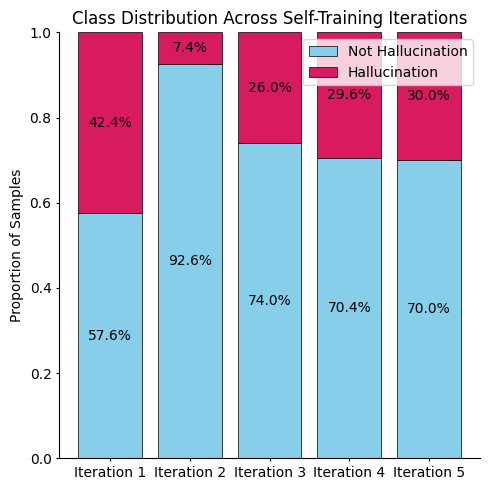

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


iterations = [1, 2, 3, 4, 5]
class_0_counts = np.array([576, 23149, 36614, 39205, 40361])
class_1_counts = np.array([424, 1849, 12893, 16450, 17313])
totals = class_0_counts + class_1_counts

class_0_pct = class_0_counts / totals
class_1_pct = class_1_counts / totals



bar_width = 0.6
x = np.arange(len(iterations))

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(x, class_0_pct, label='Not Hallucination', color='skyblue',edgecolor='black', linewidth=0.5)
ax.bar(x, class_1_pct, bottom=class_0_pct, label='Hallucination', color='#D81B60',edgecolor='black', linewidth=0.5)

for i in range(len(x)):
    ax.text(x[i], class_0_pct[i]/2, f'{class_0_pct[i]*100:.1f}%', ha='center', va='center', fontsize=10, color='black')
    ax.text(x[i], class_0_pct[i] + class_1_pct[i]/2, f'{class_1_pct[i]*100:.1f}%', ha='center', va='center', fontsize=10, color='black')

ax.set_xticks(x)
ax.set_xticklabels([f'Iteration {i}' for i in iterations])
ax.set_ylabel('Proportion of Samples')
ax.set_title('Class Distribution Across Self-Training Iterations')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('white')
ax.tick_params(axis='both', which='both', length=2)

plt.tight_layout()
plt.show()


## Effect of Active Learning on Confidence Calibration of Correctly Classified Instances

### Model 1 - Trained DeBERTa

In [ ]:
import pickle
with open('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/best2/SavedModels_1/pre_probs_test_2995.pkl', 'rb') as f:
          pred_probs = pickle.load(f)
len(pred_probs)

2995

In [ ]:
import pandas as pd
cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')].copy()
print(f"Test set size: {len(test_df)}")

Test set size: 2995


In [ ]:
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
df = pd.DataFrame({'pred_prob': pred_probs})

df['pred_label'] = (df['pred_prob'] > 0.5).astype(int)

df['true_label'] = test_df['label'].values
if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
else:
        test_probs_true = [0]*len(test_df)

accuracy = accuracy_score(df['true_label'], df['pred_label'])

spearman_corr, _ = spearmanr( test_probs_true, df['pred_prob'])

print(f"Accuracy: {accuracy:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")


print("Classification Report:")
print(classification_report(df['true_label'], df['pred_label'], digits=4))

cm = confusion_matrix(df['true_label'], df['pred_label'])
print("Confusion Matrix:")
print(cm)



Accuracy: 0.7539
Spearman Correlation: 0.6155
Classification Report:
              precision    recall  f1-score   support

           0     0.7633    0.8670    0.8118      1834
           1     0.7325    0.5754    0.6445      1161

    accuracy                         0.7539      2995
   macro avg     0.7479    0.7212    0.7282      2995
weighted avg     0.7514    0.7539    0.7470      2995

Confusion Matrix:
[[1590  244]
 [ 493  668]]


In [ ]:
correct_df = df[df['pred_label']==df['true_label']].copy()

display(correct_df.head())
print("Correctly classified: ",correct_df.shape[0])
print("Percentage of correctly classified: ", correct_df.shape[0]/test_df.shape[0])
print(f"Class balance : {correct_df.pred_label.value_counts().to_dict()} ")

,pred_prob,pred_label,true_label
0,0.007639,0,0
1,0.057313,0,0
3,0.939537,1,1
4,0.003052,0,0
6,0.016521,0,0


Correctly classified:  2258
Percentage of correctly classified:  0.7539232053422371
Class balance : {0: 1590, 1: 668} 


In [ ]:
import pandas as pd
import numpy as np
bins = [-np.inf, 0.3, 0.6, 0.8, np.inf]
labels = ['< 0.3', '0.3 – 0.6', '0.6 – 0.8', '> 0.8']

correct_df['prob_bin'] = pd.cut(correct_df['pred_prob'], bins=bins, labels=labels)

bin_counts = correct_df['prob_bin'].value_counts().sort_index()

stats_table = bin_counts.reset_index()
stats_table.columns = ['Prediction Probability Bin', 'Count']

print(stats_table)


  Prediction Probability Bin  Count
0                      < 0.3   1532
1                  0.3 – 0.6     85
2                  0.6 – 0.8    125
3                      > 0.8    516


In [ ]:

stats_table['Ratio'] = stats_table['Count']/sum(stats_table.Count)
display(stats_table)
sum(stats_table.Ratio)

,Prediction Probability Bin,Count,Ratio
0,< 0.3,1532,0.678477
1,0.3 – 0.6,85,0.037644
2,0.6 – 0.8,125,0.055359
3,> 0.8,516,0.228521


1.0

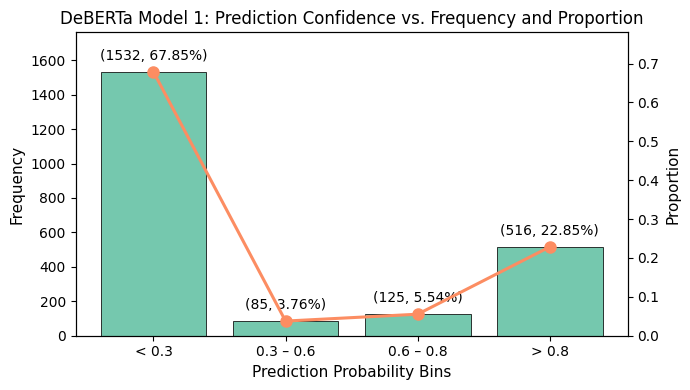

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(stats_table))
bins = stats_table['Prediction Probability Bin']
counts = stats_table['Count']
ratios = stats_table['Ratio']

fig, ax1 = plt.subplots(figsize=(7, 4))

bars = ax1.bar(
    x,
    counts,
    color='#66c2a5',
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9
)

ax1.set_xticks(x)
ax1.set_xticklabels(bins, fontsize=10, color='black')
ax1.set_ylabel('Frequency', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')
for spine in ax1.spines.values():
    spine.set_color('black')

ax2 = ax1.twinx()
ax2.plot(
    x,
    ratios,
    color='#fc8d62',
    marker='o',
    markersize=8,
    linewidth=2.2
)
ax2.set_ylabel('Proportion', color='black', fontsize=11)
ax2.tick_params(axis='y', labelcolor='black')
for spine in ['right']:
    ax2.spines[spine].set_color('black')

ax1.set_ylim(0, max(counts) * 1.15)
ax2.set_ylim(0, max(ratios) * 1.15)

y_offset = max(counts) * 0.035
for i, bar in enumerate(bars):
    cnt = counts[i]
    pct = ratios[i]
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        cnt + y_offset,
        f"({cnt}, {(pct * 100):.2f}%)",
        ha='center',
        va='bottom',
        color='black',
        fontsize=10
    )

ax1.set_xlabel('Prediction Probability Bins', color='black', fontsize=11)
ax1.set_title('DeBERTa Model 1: Prediction Confidence vs. Frequency and Proportion', fontsize=12, color='black')

plt.tight_layout()
plt.show()


### Model 2 - Active Learning Model

In [ ]:
import pickle
with open('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/SavedModels_1/pre_probs_test_2995.pkl', 'rb') as f:
          pred_probs2 = pickle.load(f)

from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
df = pd.DataFrame({'pred_prob': pred_probs2})
if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
else:
        test_probs_true = [0]*len(test_df)

df['pred_label'] = (df['pred_prob'] > 0.5).astype(int)

df['true_label'] = test_df['label'].values

accuracy = accuracy_score(df['true_label'], df['pred_label'])

spearman_corr, _ = spearmanr( test_probs_true, df['pred_prob'])

print(f"Accuracy: {accuracy:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")


print("Classification Report:")
print(classification_report(df['true_label'], df['pred_label'], digits=4))

cm = confusion_matrix(df['true_label'], df['pred_label'])
print("Confusion Matrix:")
print(cm)


Accuracy: 0.7693
Spearman Correlation: 0.6158
Classification Report:
              precision    recall  f1-score   support

           0     0.7882    0.8522    0.8190      1834
           1     0.7322    0.6382    0.6820      1161

    accuracy                         0.7693      2995
   macro avg     0.7602    0.7452    0.7505      2995
weighted avg     0.7665    0.7693    0.7659      2995

Confusion Matrix:
[[1563  271]
 [ 420  741]]


In [ ]:
correct_df = df[df['pred_label']==df['true_label']].copy()

display(correct_df.head())
print("Correctly classified: ",correct_df.shape[0])
print("Percentage of correctly classified: ", correct_df.shape[0]/test_df.shape[0])
print(f"Class balance : {correct_df.pred_label.value_counts().to_dict()} ")


,pred_prob,pred_label,true_label
0,0.004723,0,0
1,0.054681,0,0
2,0.777291,1,1
3,0.992188,1,1
4,0.001190,0,0


Correctly classified:  2304
Percentage of correctly classified:  0.7692821368948247
Class balance : {0: 1563, 1: 741} 


In [ ]:
bins = [-np.inf, 0.3, 0.6, 0.8, np.inf]
labels = ['< 0.3', '0.3 – 0.6', '0.6 – 0.8', '> 0.8']


correct_df['prob_bin'] = pd.cut(correct_df['pred_prob'], bins=bins, labels=labels)

bin_counts = correct_df['prob_bin'].value_counts().sort_index()

stats_table = bin_counts.reset_index()
stats_table.columns = ['Prediction Probability Bin', 'Count']
stats_table['Ratio'] = stats_table['Count']/sum(stats_table.Count)
display(stats_table)
sum(stats_table.Ratio)

,Prediction Probability Bin,Count,Ratio
0,< 0.3,1512,0.656250
1,0.3 – 0.6,73,0.031684
2,0.6 – 0.8,74,0.032118
3,> 0.8,645,0.279948


1.0

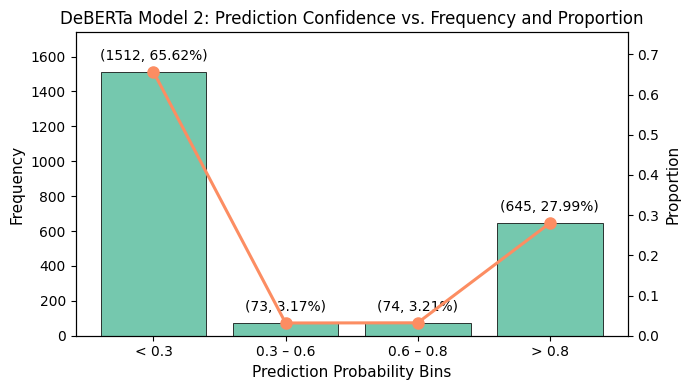

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(stats_table))
bins = stats_table['Prediction Probability Bin']
counts = stats_table['Count']
ratios = stats_table['Ratio']

fig, ax1 = plt.subplots(figsize=(7, 4))

bars = ax1.bar(
    x,
    counts,
    color='#66c2a5',
    edgecolor='black',
    linewidth=0.6,
    alpha=0.9
)

ax1.set_xticks(x)
ax1.set_xticklabels(bins, fontsize=10, color='black')
ax1.set_ylabel('Frequency', color='black', fontsize=11)
ax1.tick_params(axis='y', labelcolor='black')
for spine in ax1.spines.values():
    spine.set_color('black')

ax2 = ax1.twinx()
ax2.plot(
    x,
    ratios,
    color='#fc8d62',
    marker='o',
    markersize=8,
    linewidth=2.2
)
ax2.set_ylabel('Proportion', color='black', fontsize=11)
ax2.tick_params(axis='y', labelcolor='black')
for spine in ['right']:
    ax2.spines[spine].set_color('black')

ax1.set_ylim(0, max(counts) * 1.15)
ax2.set_ylim(0, max(ratios) * 1.15)

y_offset = max(counts) * 0.035
for i, bar in enumerate(bars):
    cnt = counts[i]
    pct = ratios[i]
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        cnt + y_offset,
        f"({cnt}, {(pct * 100):.2f}%)",
        ha='center',
        va='bottom',
        color='black',
        fontsize=10
    )

ax1.set_xlabel('Prediction Probability Bins', color='black', fontsize=11)
ax1.set_title('DeBERTa Model 2: Prediction Confidence vs. Frequency and Proportion', fontsize=12, color='black')

plt.tight_layout()
plt.show()


## Statistical Testing

In [ ]:
# Rerun saved model
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import os
from joblib import dump, load
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)


    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        sp_corr, _ = spearmanr(test_p_scores, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)

    tokenizers = [AutoTokenizer.from_pretrained(p,use_fast=False) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p).to(device) for p in model_paths]

    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)


    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")
    meta_clf_path = '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_final/meta_clf.joblib'
    meta_clf = load(meta_clf_path)
    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Debertav3_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Roberta_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df=None,
    max_iterations=5,
    batch_size=16
)


Using device: cuda
Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {0: 636, 1: 514}
Test set size: 2995


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


Final meta-classifier is trained. Evaluate one last time on test set:

Ensemble Accuracy: 0.7853

Classification Report:
              precision    recall  f1-score   support

           0     0.8200    0.8321    0.8260      1834
           1     0.7284    0.7115    0.7198      1161

    accuracy                         0.7853      2995
   macro avg     0.7742    0.7718    0.7729      2995
weighted avg     0.7845    0.7853    0.7848      2995


Confusion Matrix:
[[1526  308]
 [ 335  826]]

Spearman Correlation: 0.6711


In [ ]:
final_probs.__len__()

true_labels = test_df["label"].astype(int).tolist()
preds = (final_probs > 0.5).astype(int).tolist()
pred_probs = final_probs.tolist()

test_p_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else None


len(pred_probs), len(true_labels)

(2995, 2995)

In [ ]:
import numpy as np

def bootstrap_accuracy(y_true, y_pred, n_bootstrap=1000, seed=42):
    np.random.seed(seed)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    n = len(y_true)
    scores = []

    for _ in range(n_bootstrap):
        indices = np.random.choice(n, n, replace=True)
        acc = (y_true[indices] == y_pred[indices]).mean()
        scores.append(acc)

    scores = np.array(scores)

    mean_acc = scores.mean()
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean_acc, lower, upper

In [ ]:
from scipy.stats import spearmanr
import numpy as np

true_labels = test_df["label"].astype(int).tolist()

# Accuracy + Bootstrap CI
orig_acc = (np.array(true_labels) == np.array(preds)).mean()
_, ci_low, ci_high = bootstrap_accuracy(true_labels, preds)

print(f"Accuracy: {orig_acc:.4f} (95% CI: {ci_low:.4f} - {ci_high:.4f})")

# Spearman + p-value

sp_corr, p_val = spearmanr(test_p_scores, pred_probs)
print(f"Spearman: {sp_corr:.4f} (p = {p_val:.4f})")

Accuracy: 0.7853 (95% CI: 0.7713 - 0.8000)
Spearman: 0.6711 (p = 0.0000)


In [ ]:
def bootstrap_spearman(y_true_probs, y_pred_probs, n_bootstrap=1000, seed=42):
    np.random.seed(seed)
    n = len(y_true_probs)
    scores = []

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        corr, _ = spearmanr(
            np.array(y_true_probs)[idx],
            np.array(y_pred_probs)[idx]
        )
        if not np.isnan(corr):
          scores.append(corr)

    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

if "p(Hallucination)" in test_df.columns:
    test_p_scores = test_df["p(Hallucination)"].astype(float).tolist()

    sp_corr, p_val = spearmanr(test_p_scores, pred_probs)
    ci_low_sp, ci_high_sp = bootstrap_spearman(test_p_scores, pred_probs)

    print(f"Spearman: {sp_corr:.4f} (p = {p_val:.4f}, 95% CI: {ci_low_sp:.4f} - {ci_high_sp:.4f})")
else:
    print("Spearman not computed (no probability labels available)")

p_text = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.4f}"
print(f"Spearman: {sp_corr:.4f} ({p_text}, 95% CI: {ci_low_sp:.4f} - {ci_high_sp:.4f})")

Spearman: 0.6711 (p < 0.001, 95% CI: 0.6501 - 0.6896)


## Cross Dataset Evaluation (HaluEval)

In [ ]:
import pandas as pd
import json

data = []
with open('/content/drive/MyDrive/SHROOM-Dataset/HaluEval/general_data.json', 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping invalid JSON line: {line.strip()} - Error: {e}")

df = pd.DataFrame(data)

print("DataFrame loaded successfully. Here are the columns:")
print(df.columns.tolist())

print("\nBasic DataFrame Information:")
df.info()

print("\nMissing Values in each column:")
print(df.isnull().sum())

DataFrame loaded successfully. Here are the columns:
['ID', 'user_query', 'chatgpt_response', 'hallucination', 'hallucination_spans']

Basic DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4507 entries, 0 to 4506
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   4507 non-null   object
 1   user_query           4507 non-null   object
 2   chatgpt_response     4507 non-null   object
 3   hallucination        4507 non-null   object
 4   hallucination_spans  4507 non-null   object
dtypes: object(5)
memory usage: 176.2+ KB

Missing Values in each column:
ID                     0
user_query             0
chatgpt_response       0
hallucination          0
hallucination_spans    0
dtype: int64


In [ ]:
df.head()

,ID,user_query,chatgpt_response,hallucination,hallucination_spans
0,1,Produce a list of common words in the English ...,"the, a, and, to, in, that, is, it, of, for, wi...",no,[]
1,2,Provide a few examples of homophones.,1. allowed (permitted) and aloud (out loud)\n2...,yes,[6. hear (to perceive sound) and here (in this...
2,3,Create a chart outlining the world's populatio...,"Unfortunately, as an AI language model, I cann...",yes,[| Year | Population (in billions) |\n|------|...
3,4,Design a shape with 10 vertices (corners).,Here is an example of a shape with 10 vertices...,yes,[```\n /\\n / \ \n /____\\n /\ ...
4,5,Automatically generate a 10 by 10 multiplicati...,"Sure, here is a 10 by 10 multiplication table:...",yes,[Incomplete answer]


In [ ]:
replicated_df = df.copy()

replicated_df['hyp'] = replicated_df['chatgpt_response']
replicated_df['src'] = replicated_df['user_query']

for col in ['tgt', 'ref', 'model', 'task']:
    replicated_df[col] = ''

replicated_df['label'] = replicated_df['hallucination'].apply(
    lambda x: 1 if x == 'yes' else 0
).astype(int)


replicated_df['task'] = 'instruction-following'

replicated_df['p(Hallucination)'] = 0.0

replicated_df['combined_input'] = (
    replicated_df['hyp'].fillna('') + ' ' +
    replicated_df['src'].fillna('') + ' ' +
    replicated_df['tgt'].fillna('') + ' ' +
    replicated_df['ref'].fillna('') + ' ' +
    replicated_df['model'].fillna('') + ' ' +
    replicated_df['task'].fillna('')
)

print("Shape:", replicated_df.shape)
print("Label distribution:", replicated_df['label'].value_counts())

Shape: (4507, 14)
Label distribution: label
0    3692
1     815
Name: count, dtype: int64


In [ ]:
test_df = replicated_df.copy()
test_df.head()

,ID,user_query,chatgpt_response,hallucination,hallucination_spans,hyp,src,tgt,ref,model,task,label,p(Hallucination),combined_input
0,1,Produce a list of common words in the English ...,"the, a, and, to, in, that, is, it, of, for, wi...",no,[],"the, a, and, to, in, that, is, it, of, for, wi...",Produce a list of common words in the English ...,,,,instruction-following,0,0.0,"the, a, and, to, in, that, is, it, of, for, wi..."
1,2,Provide a few examples of homophones.,1. allowed (permitted) and aloud (out loud)\n2...,yes,[6. hear (to perceive sound) and here (in this...,1. allowed (permitted) and aloud (out loud)\n2...,Provide a few examples of homophones.,,,,instruction-following,1,0.0,1. allowed (permitted) and aloud (out loud)\n2...
2,3,Create a chart outlining the world's populatio...,"Unfortunately, as an AI language model, I cann...",yes,[| Year | Population (in billions) |\n|------|...,"Unfortunately, as an AI language model, I cann...",Create a chart outlining the world's populatio...,,,,instruction-following,1,0.0,"Unfortunately, as an AI language model, I cann..."
3,4,Design a shape with 10 vertices (corners).,Here is an example of a shape with 10 vertices...,yes,[```\n /\\n / \ \n /____\\n /\ ...,Here is an example of a shape with 10 vertices...,Design a shape with 10 vertices (corners).,,,,instruction-following,1,0.0,Here is an example of a shape with 10 vertices...
4,5,Automatically generate a 10 by 10 multiplicati...,"Sure, here is a 10 by 10 multiplication table:...",yes,[Incomplete answer],"Sure, here is a 10 by 10 multiplication table:...",Automatically generate a 10 by 10 multiplicati...,,,,instruction-following,1,0.0,"Sure, here is a 10 by 10 multiplication table:..."


In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import os
from joblib import dump, load
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

#test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")
val_df = preprocess_dataframe(val_df)
#test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        #sp_corr, _ = spearmanr(test_p_scores, final_probs)
        sp_corr, _ = spearmanr(test_labels, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)

    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]


    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)

    for iteration in range(1, max_iterations+1):
        print(f"\n========== Iteration {iteration} ==========")

        val_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            probs = predict_probs(base_model, tok, labeled_texts, batch_size=batch_size)
            val_features_list.append(probs)
        val_features = np.stack(val_features_list, axis=1)


        meta_clf = LogisticRegression()
        meta_clf.fit(val_features, labeled_labels)
        print("Trained meta-classifier on current labeled set.")


        print("Evaluation on test set (meta-clf ensemble):")
        test_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
            test_features_list.append(test_probs)
        test_features_stacked = np.stack(test_features_list, axis=1)
        _acc, _sp, _pp = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

        try:
            if _acc> 0.6 and _sp> 0:
                save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/Ensemble_QbC_HaluEval/Stacking_iter{iteration}"
                os.makedirs(save_path, exist_ok=True)


                dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
                print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")


                with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f:
                    pickle.dump(_pp, f)
                    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

        except Exception as e:
            print(f"An error occurred while saving...: {e}")


        if len(unlabeled_df) == 0:
            print("No unlabeled data left. Stopping.")
            break

        unlab_texts = unlabeled_df["combined_input"].tolist()
        unlab_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            unlab_probs = predict_probs(base_model, tok, unlab_texts, batch_size=batch_size)
            unlab_features_list.append(unlab_probs)
        unlab_features = np.stack(unlab_features_list, axis=1)

        pseudo_probs = meta_clf.predict_proba(unlab_features)[:, 1]
        pseudo_preds = (pseudo_probs > 0.5).astype(int)
        unlabeled_df['pred_labels'] = pseudo_preds
        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pseudo_probs

        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/Ensemble_QbC_HaluEval/labeled_1150_Stacking_iter_{iteration}.csv", index=False)


        print("Unlabeled overall Class balance after prediction: ",unlabeled_df.pred_labels.value_counts())

        TOP_K = 100  # Number of top confident samples to select per class

        # Sort predictions for both classes
        class_1_indices = np.argsort(-pseudo_probs)  # High to low for class 1
        class_0_indices = np.argsort(pseudo_probs)   # Low to high for class 0

        # Take up to TOP_K samples per class
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence pseudo-labels. Stopping.")
            break

        # Shuffle to avoid order bias
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Equalize lengths
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        # Select new pseudo-labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)

        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)


        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Pseudo-labeled {len(new_texts_1)} as class 1, {len(new_texts_0)} as class 0.")
        print(f"Total labeled set now size={len(labeled_texts)}")


        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy().reset_index(drop=True)
        print(f"Remaining unlabeled after iteration {iteration}: {len(unlabeled_df)}")

        if (len(new_texts_1)+len(new_texts_0)) < 10:
            print("Fewer than 10 new samples added. Stopping iterative self-training.")
            break

    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")
    meta_clf_path = '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_final/meta_clf.joblib'
    meta_clf = load(meta_clf_path)
    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Debertav3_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Roberta_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]


_, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df=None,
    max_iterations=0
)


Using device: cuda
Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {0: 636, 1: 514}
Test set size: 4507


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


Final meta-classifier is trained. Evaluate one last time on test set:

Ensemble Accuracy: 0.5878

Classification Report:
              precision    recall  f1-score   support

           0     0.8240    0.6316    0.7151      3692
           1     0.1890    0.3890    0.2544       815

    accuracy                         0.5878      4507
   macro avg     0.5065    0.5103    0.4848      4507
weighted avg     0.7092    0.5878    0.6318      4507


Confusion Matrix:
[[2332 1360]
 [ 498  317]]

No p(Hallucination) scores found for Spearman correlation.


In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/Ensemble_QbC_HaluEval/Stacking_final"
os.makedirs(save_path, exist_ok=True)

# Training data
with open(os.path.join(save_path, 'final_texts.pkl'), 'wb') as f:
    pickle.dump(final_texts, f)

with open(os.path.join(save_path, 'final_labels.pkl'), 'wb') as f:
    pickle.dump(final_labels, f)

# Test predictions
with open(os.path.join(save_path, 'final_probs.pkl'), 'wb') as f:
    pickle.dump(final_probs, f)

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'test_texts': test_df['combined_input'].tolist(),
    'test_labels': test_df['label'].tolist(),
    'final_probs': final_probs
})

comparison_df.head()
#comparison_df.to_csv('/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/Ensemble_QbC_HaluEval/Stacking_final/final_comparison.csv')

,test_texts,test_labels,final_probs
0,"the, a, and, to, in, that, is, it, of, for, wi...",0,0.997902
1,1. allowed (permitted) and aloud (out loud)\n2...,1,0.995709
2,"Unfortunately, as an AI language model, I cann...",1,0.557352
3,Here is an example of a shape with 10 vertices...,1,0.008562
4,"Sure, here is a 10 by 10 multiplication table:...",1,0.684739


In [ ]:
comparison_df['test_texts'].get(0)

'the, a, and, to, in, that, is, it, of, for, with, was, on, be, by, at, as, but, from, this, have, or, not, are, they, all, an, their, one, has, been, would, who, which, there, if, will, when, can, more, most, no, other, so, about, like, some, into, its, time, up, out, go, could, than, only, these, also, now, him, how, then, make, two, way, been, our, first, thing, may, after, too, any, day, never, same, last, long, even, new, must, here, every, such, own, down, man, people, way, little, much, world, know, good, year, take, come, us, many, again, find, much, just, see, use, get, through, back, well, still, before, without, while, between, life, go, own, off, mean, keep, own, another, put, however, almost, began, interest, show, Produce a list of common words in the English language.    instruction-following'

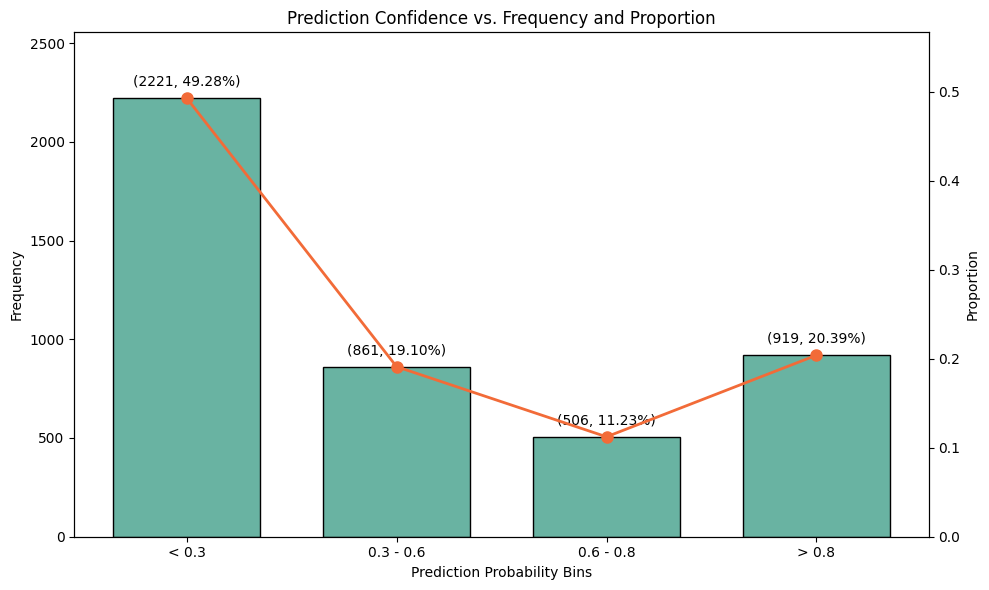

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

probs = np.array(final_probs)

bins = [0, 0.3, 0.6, 0.8, 1.0]
labels = ['< 0.3', '0.3 - 0.6', '0.6 - 0.8', '> 0.8']

counts, _ = np.histogram(probs, bins=bins)
total = len(probs)
proportions = counts / total

x = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(x, counts, width=0.7, color='#69b3a2', edgecolor='black', align='center')
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Prediction Probability Bins')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
ax2.plot(x, proportions, color='#f26b38', marker='o', linestyle='-', linewidth=2, markersize=8)
ax2.set_ylabel('Proportion')

ax1.set_ylim(0, max(counts) * 1.15)
ax2.set_ylim(0, max(proportions) * 1.15)

for i, (count, prop) in enumerate(zip(counts, proportions)):
    ax1.text(x[i], count + max(counts)*0.02,
             f"({count}, {prop*100:.2f}%)",
             ha='center', va='bottom', fontsize=10)

plt.title('Prediction Confidence vs. Frequency and Proportion')
plt.tight_layout()
plt.show()


## Zero Shot baseline comparison

### FactCC

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
labeled_df = cleaned_df[cleaned_df['label'].notna()].copy()
labeled_df['label'] = labeled_df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

if 'p(Hallucination)' not in labeled_df.columns:
    raise ValueError("Missing `p(Hallucination)` field.")

labeled_df['combined_input'] = (
    labeled_df['hyp'].fillna('') + ' ' +
    labeled_df['src'].fillna('') + ' ' +
    labeled_df['tgt'].fillna('') + ' ' +
    labeled_df['ref'].fillna('') + ' ' +
    labeled_df['model'].fillna('') + ' ' +
    labeled_df['task'].fillna('')
)

test_df = labeled_df[labeled_df['Dataset'].str.contains('Test')].copy()
print(f"Test set size: {len(test_df)}")

Using device: cuda
Test set size: 2995


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "manueldeprada/FactCC"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def build_factcc_inputs(df):
    """
    Map SHROOM fields to FactCC format.
    document = grounding context
    claim = generated output (hyp)
    """
    documents = (
        df['src'].fillna('') + ' ' +
        df['ref'].fillna('')
        #+ ' ' +
        #df['tgt'].fillna('')
    ).tolist()

    claims = df['hyp'].fillna('').tolist()

    return documents, claims


def evaluate_factcc(test_df, batch_size=8):
    documents, claims = build_factcc_inputs(test_df)

    true_labels = test_df['label'].astype(int).tolist()


    if 'p(Hallucination)' in test_df.columns:
        true_probs = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        true_probs = None

    preds = []
    probs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(documents), batch_size), desc="FactCC Evaluation"):
            batch_docs = documents[i:i+batch_size]
            batch_claims = claims[i:i+batch_size]

            encodings = tokenizer(
                batch_docs,
                batch_claims,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encodings)
            logits = outputs.logits

            batch_probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

            # FactCC: label 1 = CONSISTENT

            # consistent (1) -> non-hallucination (0)
            # inconsistent (0) -> hallucination (1)

            batch_preds = (batch_probs < 0.5).astype(int)

            preds.extend(batch_preds)
            probs.extend(1 - batch_probs)  # probability of hallucination


    acc = accuracy_score(true_labels, preds)

    print(f"\nAccuracy: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(true_labels, preds, digits=4))

    cm = confusion_matrix(true_labels, preds)
    print("\nConfusion Matrix:")
    print(cm)

    if true_probs is not None:
        sp_corr, _ = spearmanr(true_probs, probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("\nSpearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr, probs


acc, spcorr, pred_probs = evaluate_factcc(test_df, batch_size=8)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FactCC Evaluation: 100%|██████████| 375/375 [00:05<00:00, 70.12it/s]


Accuracy: 0.4347

Classification Report:
              precision    recall  f1-score   support

           0     0.6038    0.2236    0.3263      1834
           1     0.3851    0.7683    0.5131      1161

    accuracy                         0.4347      2995
   macro avg     0.4945    0.4959    0.4197      2995
weighted avg     0.5191    0.4347    0.3987      2995


Confusion Matrix:
[[ 410 1424]
 [ 269  892]]

Spearman Correlation: 0.0077


### NLI

In [ ]:
!pip install transformers torch scikit-learn scipy tqdm

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model_name = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

# Label mapping (fixed for MNLI)
# 0 = contradiction, 1 = neutral, 2 = entailment
CONTRADICTION_ID = 0


def build_inputs(df):
    """
    premise = grounding context
    hypothesis = generated output
    """
    premises = (
        df['src'].fillna('') + ' ' +
        df['ref'].fillna('')
        #+ ' ' +
        #df['tgt'].fillna('')
    ).tolist()

    hypotheses = df['hyp'].fillna('').tolist()

    return premises, hypotheses


def evaluate_deberta_nli(test_df, batch_size=8):
    premises, hypotheses = build_inputs(test_df)

    true_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        true_probs = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        true_probs = None

    preds = []
    probs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(premises), batch_size), desc="DeBERTa-MNLI Evaluation"):
            batch_premises = premises[i:i+batch_size]
            batch_hypotheses = hypotheses[i:i+batch_size]

            encodings = tokenizer(
                batch_premises,
                batch_hypotheses,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encodings)
            logits = outputs.logits

            # probabilities over [contradiction, neutral, entailment]
            probs_batch = torch.softmax(logits, dim=1).cpu().numpy()

            # hallucination score = contradiction probability
            halluc_probs = probs_batch[:, CONTRADICTION_ID]

            # binary prediction
            batch_preds = (halluc_probs > 0.5).astype(int)
            # contradiction = probs_batch[:, 0]
            # entailment = probs_batch[:, 2]

            # halluc_score = contradiction / (contradiction + entailment + 1e-8)
            # batch_preds = (halluc_score > 0.5).astype(int)

            # probs.extend(halluc_score)

            preds.extend(batch_preds)
            probs.extend(halluc_probs)

    acc = accuracy_score(true_labels, preds)

    print(f"Accuracy: {acc:.4f}\n")

    print("Classification Report:")
    print(classification_report(true_labels, preds, digits=4))

    cm = confusion_matrix(true_labels, preds)
    print("\nConfusion Matrix:")
    print(cm)

    if true_probs is not None:
        sp_corr, _ = spearmanr(true_probs, probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("\nSpearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr, probs


acc, spcorr, pred_probs = evaluate_deberta_nli(test_df, batch_size=16)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
DeBERTa-MNLI Evaluation: 100%|██████████| 188/188 [00:10<00:00, 17.35it/s]

Accuracy: 0.3523

Classification Report:
              precision    recall  f1-score   support

           0     0.4400    0.2121    0.2862      1834
           1     0.3155    0.5736    0.4071      1161

    accuracy                         0.3523      2995
   macro avg     0.3778    0.3929    0.3467      2995
weighted avg     0.3918    0.3523    0.3331      2995


Confusion Matrix:
[[ 389 1445]
 [ 495  666]]

Spearman Correlation: -0.3711


### Misclassification Analysis

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import os
from joblib import dump, load
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        sp_corr, _ = spearmanr(test_p_scores, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)

    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]

    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)

    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")
    meta_clf_path = '/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/Ensemble_QbC/Stacking_final/meta_clf.joblib'
    meta_clf = load(meta_clf_path)
    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Debertav3_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Roberta_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
)


Using device: cuda
Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {0: 636, 1: 514}
Test set size: 2995


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:02<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


Final meta-classifier is trained. Evaluate one last time on test set:

Ensemble Accuracy: 0.7853

Classification Report:
              precision    recall  f1-score   support

           0     0.8200    0.8321    0.8260      1834
           1     0.7284    0.7115    0.7198      1161

    accuracy                         0.7853      2995
   macro avg     0.7742    0.7718    0.7729      2995
weighted avg     0.7845    0.7853    0.7848      2995


Confusion Matrix:
[[1526  308]
 [ 335  826]]

Spearman Correlation: 0.6711


In [ ]:
df = test_df.copy()

df['prob'] = final_probs  # probability of hallucination
df['pred'] = (df['prob'] > 0.5).astype(int)
tp = df[(df.label == 1) & (df.pred == 1)]
fp = df[(df.label == 0) & (df.pred == 1)]
fn = df[(df.label == 1) & (df.pred == 0)]


In [ ]:
tp_samples = tp.sample(5, random_state=42)
fp_samples = fp.sample(5, random_state=42)
fn_samples = fn.sample(5, random_state=42)

In [ ]:
print(tp_samples.head(1))
print(fp_samples.head(1))
print(fn_samples.head(1))

                                                     hyp  \
62052  (transitive, intransitive) To injure or break ...   

                                                     tgt  \
62052  To weaken, as a joint, ligament, or muscle, by...   

                                             src  ref task model  \
62052  to <define> sprain </define> one 's ankle  NaN   DM   NaN   

                     Dataset  \
62052  Test (Model-Agnostic)   

                                                  labels  label  \
62052  ['Hallucination', 'Not Hallucination', 'Halluc...      1   

       p(Hallucination)      id  \
62052               0.8  1755.0   

                                          combined_input      prob  pred  
62052  (transitive, intransitive) To injure or break ...  0.998134     1  
                                hyp                       tgt  \
62426  And that's hardly happening.  That ain't gonna happen.   

                                   src  ref task model               

In [ ]:
tp_samples

,hyp,tgt,src,ref,task,model,Dataset,labels,label,p(Hallucination),id,combined_input,prob,pred
62052,"(transitive, intransitive) To injure or break ...","To weaken, as a joint, ligament, or muscle, by...",to <define> sprain </define> one 's ankle,NaN,DM,NaN,Test (Model-Agnostic),"['Hallucination', 'Not Hallucination', 'Halluc...",1,0.8,1755.0,"(transitive, intransitive) To injure or break ...",0.998134,1
60361,"Later, an elderly woman needed a toilet seat a...",The photographers later took the place of an a...,बाद मे एकटा वृद्धा कें शौचालय जेबाक आवश्यकता भ...,NaN,MT,NaN,Test (Model-Aware),"['Hallucination', 'Hallucination', 'Hallucinat...",1,1.0,1443.0,"Later, an elderly woman needed a toilet seat a...",0.997956,1
59934,To remove the scalp from .,To screen or sieve ore before further processi...,scalped ore,NaN,DM,NaN,Test (Model-Aware),"['Hallucination', 'Hallucination', 'Hallucinat...",1,1.0,591.0,To remove the scalp from . scalped ore To scre...,0.998621,1
60321,The Northern Mariana Islands' emergency respon...,The Northern Marianas emergency management off...,کنتو منجمين ضرورت ماريانا اوتارا ݢخن بهوا هانا...,NaN,MT,NaN,Test (Model-Aware),"['Hallucination', 'Not Hallucination', 'Halluc...",1,0.8,1375.0,The Northern Mariana Islands' emergency respon...,0.998665,1
60722,Extremely fast ; extremely quick .,"Very strong or intense ; excessive , tremendous .",The star tremulous turn 'd its thundering pole...,NaN,DM,NaN,Test (Model-Aware),"['Hallucination', 'Hallucination', 'Hallucinat...",1,1.0,2175.0,Extremely fast ; extremely quick . The star tr...,0.511309,1


In [ ]:
cols = ['src', 'ref', 'tgt', 'hyp', 'label', 'pred', 'prob', 'p(Hallucination)', 'task']
tp_samples = tp_samples[cols]
fp_samples = fp_samples[cols]
fn_samples = fn_samples[cols]

tp_samples

,src,ref,tgt,hyp,label,pred,prob,p(Hallucination),task
62052,to <define> sprain </define> one 's ankle,NaN,"To weaken, as a joint, ligament, or muscle, by...","(transitive, intransitive) To injure or break ...",1,1,0.998134,0.8,DM
60361,बाद मे एकटा वृद्धा कें शौचालय जेबाक आवश्यकता भ...,NaN,The photographers later took the place of an a...,"Later, an elderly woman needed a toilet seat a...",1,1,0.997956,1.0,MT
59934,scalped ore,NaN,To screen or sieve ore before further processi...,To remove the scalp from .,1,1,0.998621,1.0,DM


In [ ]:
tp_samples[:2]

,src,ref,tgt,hyp,label,pred,prob,p(Hallucination),task
62052,to <define> sprain </define> one 's ankle,NaN,"To weaken, as a joint, ligament, or muscle, by...","(transitive, intransitive) To injure or break ...",1,1,0.998134,0.8,DM
60361,बाद मे एकटा वृद्धा कें शौचालय जेबाक आवश्यकता भ...,NaN,The photographers later took the place of an a...,"Later, an elderly woman needed a toilet seat a...",1,1,0.997956,1.0,MT


In [ ]:
fp_samples[:2]

,src,ref,tgt,hyp,label,pred,prob,p(Hallucination),task
62426,And that's not going to happen.,NaN,That ain't gonna happen.,And that's hardly happening.,0,1,0.810009,0.4,PG
59720,English university students will have to pay t...,NaN,That serves as an addition,An additional payment .,0,1,0.609929,0.4,DM


In [ ]:
fn_samples = fn.sample(3, random_state=33)
fn_samples = fn_samples[cols]
fn_samples

,src,ref,tgt,hyp,label,pred,prob,p(Hallucination),task
61452,"Hey, can we talk?",NaN,Might we have a word?,"Hey, can I talk to you privately?",1,0,0.007660,0.6,PG
61958,Мэри ещё в куклы играет.,NaN,Mary still plays with dolls.,Mary's still playing dolls.,1,0,0.006868,0.6,MT
59682,"Thank you, Mrs Thyssen.",NaN,NaN,"Mrs. Thyssen, thank you for your kind words.",1,0,0.255630,0.6,PG


In [ ]:
fn_samples.iloc[[0,2]]

,src,ref,tgt,hyp,label,pred,prob,p(Hallucination),task
61452,"Hey, can we talk?",NaN,Might we have a word?,"Hey, can I talk to you privately?",1,0,0.00766,0.6,PG
59682,"Thank you, Mrs Thyssen.",NaN,NaN,"Mrs. Thyssen, thank you for your kind words.",1,0,0.25563,0.6,PG


In [ ]:
output_df = pd.concat([tp_samples[:2], fp_samples[:2], fn_samples.iloc[[0,2]]])
output_df

,src,ref,tgt,hyp,label,pred,prob,p(Hallucination),task
62052,to <define> sprain </define> one 's ankle,NaN,"To weaken, as a joint, ligament, or muscle, by...","(transitive, intransitive) To injure or break ...",1,1,0.998134,0.8,DM
60361,बाद मे एकटा वृद्धा कें शौचालय जेबाक आवश्यकता भ...,NaN,The photographers later took the place of an a...,"Later, an elderly woman needed a toilet seat a...",1,1,0.997956,1.0,MT
62426,And that's not going to happen.,NaN,That ain't gonna happen.,And that's hardly happening.,0,1,0.810009,0.4,PG
59720,English university students will have to pay t...,NaN,That serves as an addition,An additional payment .,0,1,0.609929,0.4,DM
61452,"Hey, can we talk?",NaN,Might we have a word?,"Hey, can I talk to you privately?",1,0,0.007660,0.6,PG
59682,"Thank you, Mrs Thyssen.",NaN,NaN,"Mrs. Thyssen, thank you for your kind words.",1,0,0.255630,0.6,PG


In [ ]:
output_df = output_df[['src', 'tgt', 'hyp', 'task', 'label','pred', 'prob', 'p(Hallucination)']]

In [ ]:
output_df

,src,tgt,hyp,task,label,pred,prob,p(Hallucination)
62052,to <define> sprain </define> one 's ankle,"To weaken, as a joint, ligament, or muscle, by...","(transitive, intransitive) To injure or break ...",DM,1,1,0.998134,0.8
60361,बाद मे एकटा वृद्धा कें शौचालय जेबाक आवश्यकता भ...,The photographers later took the place of an a...,"Later, an elderly woman needed a toilet seat a...",MT,1,1,0.997956,1.0
62426,And that's not going to happen.,That ain't gonna happen.,And that's hardly happening.,PG,0,1,0.810009,0.4
59720,English university students will have to pay t...,That serves as an addition,An additional payment .,DM,0,1,0.609929,0.4
61452,"Hey, can we talk?",Might we have a word?,"Hey, can I talk to you privately?",PG,1,0,0.007660,0.6
59682,"Thank you, Mrs Thyssen.",NaN,"Mrs. Thyssen, thank you for your kind words.",PG,1,0,0.255630,0.6


In [ ]:
output_df.to_csv('output_df.csv')

In [ ]:
np.mean(final_probs[df.label == 1])
np.mean(final_probs[df.label == 0])

np.float64(0.1755706357426277)

In [ ]:
import pandas as pd

df = pd.read_csv('output_df.csv')

In [ ]:
df

,Unnamed: 0,src,tgt,hyp,task,label,pred,prob,p(Hallucination)
0,62052,to <define> sprain </define> one 's ankle,"To weaken, as a joint, ligament, or muscle, by...","(transitive, intransitive) To injure or break ...",DM,1,1,0.998134,0.8
1,60361,बाद मे एकटा वृद्धा कें शौचालय जेबाक आवश्यकता भ...,The photographers later took the place of an a...,"Later, an elderly woman needed a toilet seat a...",MT,1,1,0.997956,1.0
2,62426,And that's not going to happen.,That ain't gonna happen.,And that's hardly happening.,PG,0,1,0.810009,0.4
3,59720,English university students will have to pay t...,That serves as an addition,An additional payment .,DM,0,1,0.609929,0.4
4,61452,"Hey, can we talk?",Might we have a word?,"Hey, can I talk to you privately?",PG,1,0,0.007660,0.6
5,59682,"Thank you, Mrs Thyssen.",NaN,"Mrs. Thyssen, thank you for your kind words.",PG,1,0,0.255630,0.6


## Sensitivity Analysis of the Deberta fixed samples experiments (Section 5.2.3) with Top K = 75 and 125


#### Top K = 75 Expt repeated with fixed and shuffled (75) balanced class pseudo labeling

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, tokenizer_path, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)



    config = AutoConfig.from_pretrained(tokenizer_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)

early_stop = False

def iterative_self_training(
    model_name,
    tokenizer_path,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()
    best_acc, best_sp = 0.75, 0.6
    global early_stop

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")

        model, tokenizer = train_model(
            model_name,
            tokenizer_path,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/labeled_databalance1040_nothresh_iter_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())
        # Indices above/below thresholds

        TOP_K = 75  # Number of samples you want ideally from each class

        # Sort based on confidence scores
        class_1_indices = np.argsort(-pred_probs)  # Descending for class 1 (high probs)
        class_0_indices = np.argsort(pred_probs)   # Ascending for class 0 (low probs)

        # Take up to TOP_K samples, or as many as available
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence samples found for one class. Stopping.")
            if not early_stop:
                early_stop = True
            break

        # Shuffle to avoid any order bias
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Equalize number of samples if needed
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        print(f"Sample 5 prediction confidence for each class: {iter_df.iloc[high_conf_1_idx]['pred_confidence'].tolist()[:5]}, {iter_df.iloc[high_conf_0_idx]['pred_confidence'].tolist()[:5]}")

        # Create new labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)

        # Merge
        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")

        # Remove these samples from unlabeled pool
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")

        # Add newly labeled samples to main pool
        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)

        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")


        print(f'************************** EVALUATION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if spcorr < 0 or acc < 0.7:
            print("Poor Results. Stopping self-training.")
            early_stop = True
            break
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/SavedModels1040_nothreshdatabalance{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')


        if len(new_texts) < 100:
            print("Fewer than 10 new samples. Stopping self-training.")
            if not early_stop:
              early_stop = True
            break

    return model, labeled_texts, labeled_labels


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
tokenizer_path = "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# 7.2) Self-Training

final_model, final_texts, final_labels = iterative_self_training(
    model_name=best_model_name,
    tokenizer_path = tokenizer_path,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    max_iterations=3
)

if not early_stop:
  final_model, final_tokenizer = train_model(
      model_name=best_model_name,
      tokenizer_path=tokenizer_path,
      train_texts=final_texts,
      train_labels=final_labels,
      lr=2e-5,
      batch_size=16,
      epochs=5,
      seed=999
  )
else:
  final_tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)

# 7.4) Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995
Starting Self training with microsoft/deberta-v3-large and training set size 1040

=== Iteration 1 ===


config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  874MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

...

Epoch 3 - Avg Loss: 0.1137


Train Epoch 4 Seed 999 with Labelled set size 1490: 100%|██████████| 93/93 [00:12<00:00,  7.31it/s]


Epoch 4 - Avg Loss: 0.0489


Train Epoch 5 Seed 999 with Labelled set size 1490: 100%|██████████| 93/93 [00:12<00:00,  7.31it/s]


Epoch 5 - Avg Loss: 0.0157
Test Accuracy: 0.7643
Classification Report:
              precision    recall  f1-score   support

           0     0.7730    0.8708    0.8190      1834
           1     0.7449    0.5960    0.6622      1161

    accuracy                         0.7643      2995
   macro avg     0.7589    0.7334    0.7406      2995
weighted avg     0.7621    0.7643    0.7582      2995

Confusion Matrix:
[[1597  237]
 [ 469  692]]
Spearman Correlation: 0.6223


#### Top K = 125 Expt repeated with fixed and shuffled (125) balanced class pseudo labeling

In [ ]:
import torch
import random
import numpy as np
import pandas as pd
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58609_nofuzzy40.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1040.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


class LabeledDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

class UnlabeledDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }


def train_model(model_name, tokenizer_path, train_texts, train_labels, lr=2e-5, batch_size=16, epochs=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    train_dataset = LabeledDataset(train_texts, train_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)



    config = AutoConfig.from_pretrained(tokenizer_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)


    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Train Epoch {epoch+1} Seed {seed} with Labelled set size {len(train_dataset)}"):
            optimizer.zero_grad()
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['label'].to(device)
            )
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} - Avg Loss: {total_loss/len(train_loader):.4f}")
        torch.cuda.empty_cache()
        gc.collect()

    model.eval()
    return model, tokenizer


def predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=8):
    ds = UnlabeledDataset(unlabeled_texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    probs = []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            probs.extend(batch_probs)
    return np.array(probs)

early_stop = False

def iterative_self_training(
    model_name,
    tokenizer_path,
    train_df,
    unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    max_iterations=5
):
    labeled_texts = train_df['combined_input'].tolist()
    labeled_labels = train_df['label'].astype(int).tolist()
    best_acc, best_sp = 0.75, 0.6
    global early_stop

    for iteration in range(1, max_iterations+1):
        print(f"\n=== Iteration {iteration} ===")

        model, tokenizer = train_model(
            model_name,
            tokenizer_path,
            labeled_texts, labeled_labels,
            lr=lr, batch_size=batch_size, epochs=epochs,
            seed=42+iteration  # for slight variation each iteration
        )

        unlabeled_texts = unlabeled_df['combined_input'].tolist()
        pred_probs = predict_unlabeled(model, tokenizer, unlabeled_texts, batch_size=batch_size)

        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pred_probs
        iter_df['pred_labels'] = (pred_probs > 0.5).astype(int)
        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/labeled_databalance1040_nothresh_k125_iter_{iteration}.csv", index=False)
        print("Unlabeled overall Class balance after prediction: ",iter_df.pred_labels.value_counts())
        # Indices above/below thresholds

        TOP_K = 125  # Number of samples you want ideally from each class

        # Sort based on confidence scores
        class_1_indices = np.argsort(-pred_probs)  # Descending for class 1 (high probs)
        class_0_indices = np.argsort(pred_probs)   # Ascending for class 0 (low probs)

        # Take up to TOP_K samples, or as many as available
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence samples found for one class. Stopping.")
            if not early_stop:
                early_stop = True
            break

        # Shuffle to avoid any order bias
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Equalize number of samples if needed
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        print(f"Sample 5 prediction confidence for each class: {iter_df.iloc[high_conf_1_idx]['pred_confidence'].tolist()[:5]}, {iter_df.iloc[high_conf_0_idx]['pred_confidence'].tolist()[:5]}")

        # Create new labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)
        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)

        # Merge
        new_texts = new_texts_1 + new_texts_0
        new_labels = new_labels_1 + new_labels_0

        print(f"Newly added samples => 1-class: {len(new_texts_1)}, 0-class: {len(new_texts_0)}")

        # Remove these samples from unlabeled pool
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy()
        unlabeled_df.reset_index(drop=True, inplace=True)
        print(f"Remaining unlabeled after iteration: {len(unlabeled_df)}")

        # Add newly labeled samples to main pool
        labeled_texts.extend(new_texts)
        labeled_labels.extend(new_labels)

        print(f"Total labeled after iteration: {len(labeled_texts)}")
        print(f"Class balance (Labeled w/ High Confidence): {pd.DataFrame(labeled_labels)[0].value_counts().to_dict()}")


        print(f'************************** EVALUATION ON TEST SET - {iteration} ************************* ')
        acc, spcorr,pred_probs = evaluate_on_test(model, tokenizer, test_df, batch_size=8)
        if spcorr < 0 or acc < 0.7:
            print("Poor Results. Stopping self-training.")
            early_stop = True
            break
        if acc> best_acc or spcorr> best_sp:
            best_acc, best_sp = acc, spcorr
            save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/SavedModels1040_nothreshdatabalance_k125_{iteration}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)

            with open(save_path+'/pre_probs_test_2995.pkl', 'wb') as f:
              pickle.dump(pred_probs, f)
              print(save_path+'/pre_probs_test_2995.pkl')


        if len(new_texts) < 100:
            print("Fewer than 10 new samples. Stopping self-training.")
            if not early_stop:
              early_stop = True
            break

    return model, labeled_texts, labeled_labels


from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import spearmanr
def evaluate_on_test(model, tokenizer, test_df, batch_size=8):
    test_texts = test_df['combined_input'].tolist()
    test_labels = test_df['label'].astype(int).tolist()

    if 'p(Hallucination)' in test_df.columns:
        test_probs_true = test_df['p(Hallucination)'].astype(float).tolist()
    else:
        test_probs_true = [0]*len(test_df)

    ds = LabeledDataset(test_texts, test_labels, tokenizer=tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds, probs, truelabels = [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            batch_probs = torch.softmax(outputs.logits, dim=1)[:,1].cpu().numpy()
            batch_preds = (batch_probs > 0.5).astype(int)
            preds.extend(batch_preds)
            probs.extend(batch_probs)
            truelabels.extend(batch['label'].cpu().numpy())

    acc = accuracy_score(truelabels, preds)
    print(f"Test Accuracy: {acc:.4f}")

    print("Classification Report:")
    print(classification_report(truelabels, preds, digits=4))

    cm = confusion_matrix(truelabels, preds)
    print("Confusion Matrix:")
    print(cm)

    if sum(test_probs_true) > 0:
        sp_corr, _ = spearmanr(test_probs_true, probs)
        print(f"Spearman Correlation: {sp_corr:.4f}")
    else:
        sp_corr = None
        print("Spearman not calculated (no p(Hallucination) in test)")

    return acc, sp_corr,probs

train_df = val_df  # rename for clarity
best_model_name = "microsoft/deberta-v3-large"
tokenizer_path = "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels1040_nothreshdatabalance3/"
print(f"Starting Self training with {best_model_name} and training set size {len(train_df)}")

# Self-Training

final_model, final_texts, final_labels = iterative_self_training(
    model_name=best_model_name,
    tokenizer_path = tokenizer_path,
    train_df=train_df,
    unlabeled_df=unlabeled_df,
    lr=2e-5,
    batch_size=16,
    epochs=5,
    max_iterations=3
)

if not early_stop:
  final_model, final_tokenizer = train_model(
      model_name=best_model_name,
      tokenizer_path=tokenizer_path,
      train_texts=final_texts,
      train_labels=final_labels,
      lr=2e-5,
      batch_size=16,
      epochs=5,
      seed=999
  )
else:
  final_tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)

# Evaluate on Test
acc, spcorr,pred_probs = evaluate_on_test(final_model, final_tokenizer, test_df, batch_size=8)


Using device: cuda
Unlabeled set size: 58609
Validation set size: 1040
Validation set balance: {0: 596, 1: 444}
Test set size: 2995
Starting Self training with microsoft/deberta-v3-large and training set size 1040

=== Iteration 1 ===


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.de

Epoch 1 - Avg Loss: 0.6637


Train Epoch 2 Seed 43 with Labelled set size 1040: 100%|██████████| 65/65 [00:08<00:00,  7.29it/s]


...

Epoch 3 - Avg Loss: 0.0979


Train Epoch 4 Seed 999 with Labelled set size 1790: 100%|██████████| 111/111 [00:15<00:00,  7.25it/s]


Epoch 4 - Avg Loss: 0.0646


Train Epoch 5 Seed 999 with Labelled set size 1790: 100%|██████████| 111/111 [00:15<00:00,  7.25it/s]


Epoch 5 - Avg Loss: 0.0454
Test Accuracy: 0.7503
Classification Report:
              precision    recall  f1-score   support

           0     0.8205    0.7579    0.7880      1834
           1     0.6587    0.7382    0.6962      1161

    accuracy                         0.7503      2995
   macro avg     0.7396    0.7480    0.7421      2995
weighted avg     0.7578    0.7503    0.7524      2995

Confusion Matrix:
[[1390  444]
 [ 304  857]]
Spearman Correlation: 0.6176


## Sensitivity Analysis of the Final Proposed Framework

### Top K = 75 Finalized Framework

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import os
from joblib import dump, load
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        sp_corr, _ = spearmanr(test_p_scores, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,      # List of paths to base models
    val_df,           # Labeled validation set (with 'combined_input', 'label')
    test_df,          # Test set (with 'combined_input', 'label', optional 'p(Hallucination)')
    unlabeled_df,     # Unlabeled set (with 'combined_input')
    max_iterations=5,
    batch_size=16
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)

    # Load base models + tokenizers
    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]

    # Separate columns
    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)

    for iteration in range(1, max_iterations+1):
        print(f"\n========== Iteration {iteration} ==========")
        # Build features from each base model on current labeled set
        val_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            probs = predict_probs(base_model, tok, labeled_texts, batch_size=batch_size)
            val_features_list.append(probs)
        val_features = np.stack(val_features_list, axis=1)

        # Train meta-classifier
        meta_clf = LogisticRegression()
        meta_clf.fit(val_features, labeled_labels)
        print("Trained meta-classifier on current labeled set.")

        # Evaluate on test set
        print("Evaluation on test set (meta-clf ensemble):")
        test_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
            test_features_list.append(test_probs)
        test_features_stacked = np.stack(test_features_list, axis=1)
        _acc, _sp, _pp = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

        try:
            if _acc> 0.6 and _sp> 0:
                save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_iter{iteration}"
                os.makedirs(save_path, exist_ok=True)

                # Save model using joblib
                dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
                print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

                # Save prediction probabilities
                with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f:
                    pickle.dump(_pp, f)
                    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

        except Exception as e:
            print(f"An error occurred while saving...: {e}")


        # Predict on unlabeled + filter pseudo-labels
        if len(unlabeled_df) == 0:
            print("No unlabeled data left. Stopping.")
            break

        unlab_texts = unlabeled_df["combined_input"].tolist()
        unlab_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            unlab_probs = predict_probs(base_model, tok, unlab_texts, batch_size=batch_size)
            unlab_features_list.append(unlab_probs)
        unlab_features = np.stack(unlab_features_list, axis=1)

        pseudo_probs = meta_clf.predict_proba(unlab_features)[:, 1]
        pseudo_preds = (pseudo_probs > 0.5).astype(int)
        unlabeled_df['pred_labels'] = pseudo_preds
        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pseudo_probs

        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/labeled_1150_Stacking_iter_{iteration}.csv", index=False)


        print("Unlabeled overall Class balance after prediction: ",unlabeled_df.pred_labels.value_counts())

        TOP_K = 75  # Number of top confident samples to select per class

        # Sort predictions for both classes
        class_1_indices = np.argsort(-pseudo_probs)  # High to low for class 1
        class_0_indices = np.argsort(pseudo_probs)   # Low to high for class 0

        # Take up to TOP_K samples per class
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence pseudo-labels. Stopping.")
            break

        # Shuffle to avoid order bias
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Equalize lengths
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        # Select new pseudo-labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)

        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)

        # Merge them into labeled set
        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Pseudo-labeled {len(new_texts_1)} as class 1, {len(new_texts_0)} as class 0.")
        print(f"Total labeled set now size={len(labeled_texts)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy().reset_index(drop=True)
        print(f"Remaining unlabeled after iteration {iteration}: {len(unlabeled_df)}")

        if (len(new_texts_1)+len(new_texts_0)) < 10:
            print("Fewer than 10 new samples added. Stopping iterative self-training.")
            break

    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")

    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Debertav3_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Roberta_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
)


Using device: cuda
Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {0: 636, 1: 514}
Test set size: 2995


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


========== Iteration 1 ==========
Trained meta-classifier on current labeled set.
Evaluation on test set (meta-clf ensemble):

Ensemble Accuracy: 0.7823

Classification Report:
              precision    recall  f1-score   support

           0     0.8114    0.8397    0.8253      1834
           1     0.7320    0.6916    0.7112      1161

    accuracy                         0.7823      2995
   macro avg     0.7717    0.7657    0.7683      2995
weighted avg     0.7806    0.7823    0.7811      2995


Confusion Matrix:
[[1540  294]
 [ 358  803]]

Spearman Correlation: 0.6704
Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_iter1/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_iter1/pre_probs_test_2995.pkl
Unlabeled overall Class balance after prediction:  pred_labels
0    39216
1    19283
Name: count, dtype: int64
Pseudo-labeled 75 as 

In [ ]:
save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_final"
os.makedirs(save_path, exist_ok=True)

# Save model using joblib
dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

# Save prediction probabilities
with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f :
    pickle.dump(final_probs, f)
    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_final/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_final/pre_probs_test_2995.pkl


### Top K = 125 Finalized Framework

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import spearmanr
from tqdm import tqdm
import os
from joblib import dump, load
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cleaned_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/cleaned_shroom_dataset.csv")
unlabeled_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/unlabeled_58499_nofuzzy150.csv")

unlabeled_df['combined_input'] = (
    unlabeled_df['hyp'].fillna('') + ' ' +
    unlabeled_df['src'].fillna('') + ' ' +
    unlabeled_df['tgt'].fillna('') + ' ' +
    unlabeled_df['ref'].fillna('') + ' ' +
    unlabeled_df['model'].fillna('') + ' ' +
    unlabeled_df['task'].fillna('')
)

test_df = cleaned_df[cleaned_df['Dataset'].str.contains('Test')]

def preprocess_dataframe(df):
    df = df.copy()
    df['label'] = df['label'].apply(lambda x: 1 if x == 'Hallucination' else 0).astype(int)

    # Create combined input
    df['combined_input'] = (
        df['hyp'].fillna('') + ' ' +
        df['src'].fillna('') + ' ' +
        df['tgt'].fillna('') + ' ' +
        df['ref'].fillna('') + ' ' +
        df['model'].fillna('') + ' ' +
        df['task'].fillna('')
    )
    return df

val_df = pd.read_csv("/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials/val_df_1150.csv")
val_df = preprocess_dataframe(val_df)
test_df = preprocess_dataframe(test_df)

print(f"Unlabeled set size: {len(unlabeled_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Validation set balance: {(val_df.label.value_counts().to_dict())}")
print(f"Test set size: {len(test_df)}")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

class SimpleDataset(Dataset):
    """Basic dataset class for generating predictions from a single model."""
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encodings['input_ids'].squeeze(0),
            'attention_mask': encodings['attention_mask'].squeeze(0)
        }

def predict_probs(model, tokenizer, texts, batch_size=8):
    """Returns the probability of class=1 for each text using a single model."""
    ds = SimpleDataset(texts, tokenizer)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)

def evaluate_ensemble(meta_clf, test_features, test_labels, test_p_scores):
    """Evaluate final ensemble predictions on test set, measuring classification metrics and Spearman correlation."""
    final_probs = meta_clf.predict_proba(test_features)[:, 1]
    final_preds = (final_probs > 0.5).astype(int)

    acc = accuracy_score(test_labels, final_preds)
    print(f"\nEnsemble Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(test_labels, final_preds, digits=4))

    cm = confusion_matrix(test_labels, final_preds)
    print("\nConfusion Matrix:")
    print(cm)

    sp_corr = None
    if np.sum(test_p_scores) > 0:
        sp_corr, _ = spearmanr(test_p_scores, final_probs)
        print(f"\nSpearman Correlation: {sp_corr:.4f}")
    else:
        print("\nNo p(Hallucination) scores found for Spearman correlation.")

    return acc, sp_corr, final_probs

from joblib import dump
import os
import pickle

def iterative_self_training_with_meta(
    model_paths,      # List of paths to base models
    val_df,           # Labeled validation set (with 'combined_input', 'label')
    test_df,          # Test set (with 'combined_input', 'label', optional 'p(Hallucination)')
    unlabeled_df,     # Unlabeled set (with 'combined_input')
    max_iterations=5,
    batch_size=16
):
    """
    1) Each iteration:
       - Train logistic regression ensemble on the labeled set (val_df).
       - Predict on unlabeled set with each base model, combine probabilities as features -> meta classifier output
       - Filter high-confidence pseudo-labels (≥ high_threshold => class1, ≤ low_threshold => class0)
       - Add them to val_df
    2) Evaluate on test_df each iteration.
    3) Return final meta classifier plus final val_df
    """

    set_seed(42)

    # Load base models + tokenizers
    tokenizers = [AutoTokenizer.from_pretrained(p) for p in model_paths]
    base_models = [AutoModelForSequenceClassification.from_pretrained(p, num_labels=2, ignore_mismatched_sizes=True).to(device) for p in model_paths]

    # Separate columns
    labeled_texts = val_df["combined_input"].tolist()
    labeled_labels = val_df["label"].astype(int).tolist()

    test_texts = test_df["combined_input"].tolist()
    test_labels = test_df["label"].astype(int).tolist()
    test_scores = test_df["p(Hallucination)"].astype(float).tolist() if "p(Hallucination)" in test_df.columns else [0]*len(test_df)

    for iteration in range(1, max_iterations+1):
        print(f"\n========== Iteration {iteration} ==========")
        # Build features from each base model on current labeled set
        val_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            probs = predict_probs(base_model, tok, labeled_texts, batch_size=batch_size)
            val_features_list.append(probs)
        val_features = np.stack(val_features_list, axis=1)

        # Train meta-classifier
        meta_clf = LogisticRegression()
        meta_clf.fit(val_features, labeled_labels)
        print("Trained meta-classifier on current labeled set.")

        # Evaluate on test set
        print("Evaluation on test set (meta-clf ensemble):")
        test_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
            test_features_list.append(test_probs)
        test_features_stacked = np.stack(test_features_list, axis=1)
        _acc, _sp, _pp = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

        try:
            if _acc> 0.6 and _sp> 0:
                save_path = f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_k125_iter{iteration}"
                os.makedirs(save_path, exist_ok=True)

                # Save model using joblib
                dump(meta_clf, os.path.join(save_path, 'meta_clf.joblib'))
                print(f"Meta-classifier saved to: {save_path}/meta_clf.joblib")

                # Save prediction probabilities
                with open(os.path.join(save_path, 'pre_probs_test_2995.pkl'), 'wb') as f:
                    pickle.dump(_pp, f)
                    print(f"Prediction probabilities saved to: {save_path}/pre_probs_test_2995.pkl")

        except Exception as e:
            print(f"An error occurred while saving...: {e}")


        # Predict on unlabeled + filter pseudo-labels
        if len(unlabeled_df) == 0:
            print("No unlabeled data left. Stopping.")
            break

        unlab_texts = unlabeled_df["combined_input"].tolist()
        unlab_features_list = []
        for base_model, tok in zip(base_models, tokenizers):
            unlab_probs = predict_probs(base_model, tok, unlab_texts, batch_size=batch_size)
            unlab_features_list.append(unlab_probs)
        unlab_features = np.stack(unlab_features_list, axis=1)

        pseudo_probs = meta_clf.predict_proba(unlab_features)[:, 1]
        pseudo_preds = (pseudo_probs > 0.5).astype(int)
        unlabeled_df['pred_labels'] = pseudo_preds
        iter_df = unlabeled_df.copy()
        iter_df['pred_confidence'] = pseudo_probs

        iter_df.to_csv(f"/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/labeled_1150_Stacking_k125_iter_{iteration}.csv", index=False)


        print("Unlabeled overall Class balance after prediction: ",unlabeled_df.pred_labels.value_counts())

        TOP_K = 125  # Number of top confident samples to select per class

        # Sort predictions for both classes
        class_1_indices = np.argsort(-pseudo_probs)  # High to low for class 1
        class_0_indices = np.argsort(pseudo_probs)   # Low to high for class 0

        # Take up to TOP_K samples per class
        high_conf_1_idx = class_1_indices[:min(TOP_K, len(class_1_indices))]
        high_conf_0_idx = class_0_indices[:min(TOP_K, len(class_0_indices))]

        # Safety check
        if len(high_conf_1_idx) == 0 or len(high_conf_0_idx) == 0:
            print("No high-confidence pseudo-labels. Stopping.")
            break

        # Shuffle to avoid order bias
        np.random.shuffle(high_conf_1_idx)
        np.random.shuffle(high_conf_0_idx)

        # Equalize lengths
        min_len = min(len(high_conf_1_idx), len(high_conf_0_idx))
        high_conf_1_idx = high_conf_1_idx[:min_len]
        high_conf_0_idx = high_conf_0_idx[:min_len]

        # Select new pseudo-labeled samples
        new_texts_1 = unlabeled_df.iloc[high_conf_1_idx]['combined_input'].tolist()
        new_labels_1 = [1] * len(new_texts_1)

        new_texts_0 = unlabeled_df.iloc[high_conf_0_idx]['combined_input'].tolist()
        new_labels_0 = [0] * len(new_texts_0)

        # Merge them into labeled set
        labeled_texts.extend(new_texts_1 + new_texts_0)
        labeled_labels.extend(new_labels_1 + new_labels_0)
        print(f"Pseudo-labeled {len(new_texts_1)} as class 1, {len(new_texts_0)} as class 0.")
        print(f"Total labeled set now size={len(labeled_texts)}")

        # Remove these from unlabeled
        keep_idx = set(range(len(unlabeled_df))) - set(high_conf_1_idx) - set(high_conf_0_idx)
        unlabeled_df = unlabeled_df.iloc[list(keep_idx)].copy().reset_index(drop=True)
        print(f"Remaining unlabeled after iteration {iteration}: {len(unlabeled_df)}")

        if (len(new_texts_1)+len(new_texts_0)) < 10:
            print("Fewer than 10 new samples added. Stopping iterative self-training.")
            break

    print("\nFinal meta-classifier is trained. Evaluate one last time on test set:")

    test_features_list = []
    for base_model, tok in zip(base_models, tokenizers):
        test_probs = predict_probs(base_model, tok, test_texts, batch_size=batch_size)
        test_features_list.append(test_probs)
    test_features_stacked = np.stack(test_features_list, axis=1)
    final_acc, final_spcorr, final_probs = evaluate_ensemble(meta_clf, test_features_stacked, test_labels, test_scores)

    return meta_clf, labeled_texts, labeled_labels, final_acc, final_spcorr, final_probs


model_paths = [
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Debertav3_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/FinalModels/SavedModels1040_Roberta_nothreshbalance3/",
        "/content/drive/MyDrive/SHROOM-Dataset/TrainedModels/Trials5/SavedModels_ElectraNewthresh"
    ]
meta_clf, final_texts, final_labels, final_acc, final_sp, final_probs = iterative_self_training_with_meta(
    model_paths,
    val_df,
    test_df,
    unlabeled_df,
    max_iterations=5,
    batch_size=16
)


Using device: cuda
Unlabeled set size: 58499
Validation set size: 1150
Validation set balance: {0: 636, 1: 514}
Test set size: 2995


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]


========== Iteration 1 ==========
Trained meta-classifier on current labeled set.
Evaluation on test set (meta-clf ensemble):

Ensemble Accuracy: 0.7823

Classification Report:
              precision    recall  f1-score   support

           0     0.8114    0.8397    0.8253      1834
           1     0.7320    0.6916    0.7112      1161

    accuracy                         0.7823      2995
   macro avg     0.7717    0.7657    0.7683      2995
weighted avg     0.7806    0.7823    0.7811      2995


Confusion Matrix:
[[1540  294]
 [ 358  803]]

Spearman Correlation: 0.6704
Meta-classifier saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_k125_iter1/meta_clf.joblib
Prediction probabilities saved to: /content/drive/MyDrive/SHROOM-Dataset/TrainedModels/SensitivityTestModels_QbC/Stacking_k125_iter1/pre_probs_test_2995.pkl
Unlabeled overall Class balance after prediction:  pred_labels
0    39216
1    19283
Name: count, dtype: int64
Pseudo-labe